<img src = "https://www.journalism.co.uk/assets/135/IiB_screenshot.jpg_resized_460_.jpeg" align = right width = 450>
<h1 align = left> Data 765: Python Fundamentals for Data Science</h1>
<h2 align = left> Lecture 14 | Exploratory Data Analysis (III) </h2>
<h3 align = left> Yinxian Zhang | QC Sociology</h3>

# Table of Contents

<div class = "alert alert-info">

1. [Data Preparation](#1)<br>
2. [Multivariate Analysis](#2)<br>
    2.1 [one numerical and two categorical](#2.1)<br>
    2.2 [one numerical and three or more categorical](#2.2)<br>
    2.3 [two numericals and one categorical](#2.3)<br>
    2.4 [multiple numericals](#2.3)<br>
3. [Saving Working Data](#3)<br>
    
</div>
<hr>

This is our final session about EDA. We will import one new libary today:

In [1]:
import pandas as pd                
import numpy as np   
import matplotlib.pyplot as plt                     
import seaborn as sns                               # a new viz library!
%matplotlib inline

---

# Data Preparation <a id=1></a>

We have explored the 2012 GSS dataset in the past couple of weeks. So let's quickly go over what we did and prepare the dataset for analysis and visualization.

In [2]:
path = 'https://raw.githubusercontent.com/UC-MACSS/persp-analysis/master/assignments/exploratory-data-analysis/data/gss2012.csv'

df = pd.read_csv(path, header=0)           

We will skip the process of initial inspection and jump right into the variables of interest. At this point, you should be very familiar with this process.

In [3]:
data =  df[['pres08',             # dv                  
            'polviews',           # iv                       
            'id',                 # for headcount
            'age', 'sex', 'race', 'educ', 'tvhours', 'income06'   # controls                                                          
           ]]                        

Again, after reading in data, your primary task is to explore the dataset with the below questions in mind: 

- are there any **missing values**? Would the missing values influence my analysis?
- are there **illegal inputs** / special values that may affect my analysis? 
- are the variables in the desired **`dtype`s and formats**? 
- for numerical variables: what are the **measuring units**? are they discrete or continuous? 
- for categorial variables: how are they **coded**? are they **nominal or ordinal**?
- do I need to **recode** some of the variables?
- what are the **distributions** of the variables? Any **outliers or pecularities** that warrant further investigation?
- ...

We already explored each of the variables in the last couple of lectures, and we found a few issues:

1. clumsy variable names;
2. wrong `dtype` for `id`;
3. unordered categories under `polviews`;
3. too many (unordered) categories under `educ`; and
4. a lot of missing values of `pres08`.

Now let's transform the data based on the findings from previous sessions. 

In [4]:
# change variable names:

data = data.rename(columns={'pres08':'pres', 
                            'polviews':'pol',
                            'income06': 'income'})    # for demo purposes only

data.columns

Index(['pres', 'pol', 'id', 'age', 'sex', 'race', 'educ', 'tvhours', 'income'], dtype='object')

In [5]:
# change dtypes:

data['id'] = data.id.astype('object')

In [6]:
# specify ordinal categorical variables:

data.pol = pd.Categorical(data.pol, 
            categories=['ExtrmLib', 'Liberal', 'SlghtLib', 'Moderate', 'SlghtCons', 'Conserv', 'ExtrmCons'],   # with order
            ordered=True)

In [7]:
data.pol.unique()              # double check

['Moderate', 'SlghtCons', 'Liberal', 'Conserv', 'ExtrmLib', NaN, 'ExtrmCons', 'SlghtLib']
Categories (7, object): ['ExtrmLib' < 'Liberal' < 'SlghtLib' < 'Moderate' < 'SlghtCons' < 'Conserv' < 'ExtrmCons']

### ▲ The `pd.Categorical` command takes the original values of the categories as inputs. You CANNOT rename or merge categories here!

### ▲ Please be very careful about typing. You cannot make any typos!

In [8]:
# merge / collapse categories:

data.educ.unique()                # 21 levels, un-ordered

array(['4 years', '12th grade', '1 yr coll', '7 years', '3 years',
       '11th grade', '9th grade', '5 years', '10th grade', '4th grade',
       'None', '2 years', '6 years', '8 years', '8th grade', '6th grade',
       '5th grade', '7th grade', nan, '3rd grade', '1st grade',
       '2nd grade'], dtype=object)

In [9]:
def recode(s):
    '''
    Input:
    s: string, the original values of the `educ` variable
    
    Output:
    recode: 4 categories representing different educational levels.
    '''
    if pd.isna(s):                  
        return np.nan                 # deal with missing values first
    
    if s == 'None':
        recode = 'no education'
    
    elif 'grade' in s:           
        recode = 'high school and below'    
        
    elif s in ['1 yr coll', '2 years', '3 years', '4 years']:      # manual typing is prone to mistakes
        recode = 'some college'
    
    elif s in ['5 years', '6 years', '7 years', '8 years']:
        recode = 'graduate level'
    
    else:
        print('error')                # helpful for debug: if there are other unexpected inputs, print it out
        print(s)
    
    return recode    

In [10]:
# again, don't over write the orginal variable!

data['educ_recoded'] = data.educ.apply(recode)

In [11]:
data[['educ', 'educ_recoded']]          # double check 

,educ,educ_recoded
0,4 years,some college
1,12th grade,high school and below
2,12th grade,high school and below
3,1 yr coll,some college
4,4 years,some college
...,...,...
1969,4 years,some college
1970,1 yr coll,some college
1971,1 yr coll,some college
1972,12th grade,high school and below


In [12]:
# specify the ordering

data["educ_recoded"] = pd.Categorical(data.educ_recoded, 
                                      categories=["no education", "high school and below", "some college", "graduate level"], 
                                      ordered = True)


In [13]:
data.educ_recoded.unique()         # double check

['some college', 'high school and below', 'graduate level', 'no education', NaN]
Categories (4, object): ['no education' < 'high school and below' < 'some college' < 'graduate level']

Some variables, such as `income`, are categorical **ordinal** variables with many levels (25 levels for income). So sometimes it makes sense to **treat them as numerical variables** in statistical analysis and visualization. 

However, this should be done with caution and you should be aware of the caveats!

In [14]:
# turn ordinal categorical variables into numerical variables
data.income.unique()                           

array(['$150000 OR OVER', '$110000 TO $129999', '$130000 TO $149999',
       '$50000 TO 59999', '$25000 TO 29999', '$30000 TO 34999',
       '$5 000 TO 5 999', 'UNDER $1 000', '$8 000 TO 9 999',
       '$22500 TO 24999', nan, '$40000 TO 49999', '$60000 TO 74999',
       '$90000 TO $109999', '$75000 TO $89999', '$35000 TO 39999',
       '$15000 TO 17499', '$20000 TO 22499', '$6 000 TO 6 999',
       '$17500 TO 19999', '$12500 TO 14999', '$10000 TO 12499',
       '$1 000 TO 2 999', '$7 000 TO 7 999', '$4 000 TO 4 999',
       '$3 000 TO 3 999'], dtype=object)

In [15]:
# define a function to automatically sort the levels and convert them to numbers 

def income_convertion(s):           # apply on each row, so each s is a value of "income06"
    '''
    dosctrings omitted here
    BUT YOU SHOULD NOT OMIT THE DOCSTRINGS IN YOUR ASSIGNMENT
    '''
    
    if 'UNDER' in s:                # special case 1
        avg = 1000                      
    
    elif 'OVER' in s:               # special case 2
        avg = 150000
        
    elif 'TO' in s:                 # common cases                            
        income = s.split('TO')
        
        lower = ''   
        for i in income[0]:
            if i.isdigit():
                lower += i
                
        higher = ''
        for j in income[1]:
            if j.isdigit():
                higher += j
                
        avg = (int(lower) + int(higher))/2     # convert str to int, calculate avg
        
    else:
        print('error')                  # deal with unexpected errors
        print(s)
    
    return avg                          # return the avg incomebv  

### Note: `NaN` is of `float` type, and may cause problems in many operations. You may need to `dropna()` before you apply a function to the dataframe.

In [16]:
data['avg_income'] = data.income.dropna().apply(income_convertion)    

In [17]:
# double check

data.income.value_counts()

$60000 TO 74999       153
$40000 TO 49999       151
$75000 TO $89999      151
$150000 OR OVER       144
$50000 TO 59999       118
$90000 TO $109999     104
$35000 TO 39999       101
$25000 TO 29999        93
$30000 TO 34999        89
$10000 TO 12499        77
$110000 TO $129999     68
$20000 TO 22499        66
$12500 TO 14999        63
$22500 TO 24999        60
$15000 TO 17499        58
$17500 TO 19999        48
$130000 TO $149999     45
$8 000 TO 9 999        38
$1 000 TO 2 999        25
$7 000 TO 7 999        24
UNDER $1 000           24
$6 000 TO 6 999        22
$3 000 TO 3 999        18
$4 000 TO 4 999        10
$5 000 TO 5 999         8
Name: income, dtype: int64

In [18]:
check = sorted(data.avg_income.dropna().unique())
check

[1000.0,
 1999.5,
 3499.5,
 4499.5,
 5499.5,
 6499.5,
 7499.5,
 8999.5,
 11249.5,
 13749.5,
 16249.5,
 18749.5,
 21249.5,
 23749.5,
 27499.5,
 32499.5,
 37499.5,
 44999.5,
 54999.5,
 67499.5,
 82499.5,
 99999.5,
 119999.5,
 139999.5,
 150000.0]

In [19]:
# double check

print(data.income.nunique(), data.avg_income.nunique())

25 25


### ▲ Although being numerical, this variable contain only 25 unique values. They are discrete (rather than continuous), and do not contain many (unique) data points. This may create problems for statistical analysis and visualization (i.e., the "overplotting" issue where many dots sit on top of each other so you can't tell how many data points there are and it does not show a clear pattern), and many data scientists / sociologists would not recommend this type of conversion due to this issue. 

# Quick Review of Bivariate Analysis <a id=2></a>

In our last lecture, we talked about how to do univariate and bivariate analysis and obtain descriptive statistics and simple visualizations. The most important thing is to know the type of your variables:

### ▲ You have to use different analysis/visualization tools for each type of variable. 
But today we will NOT review the details of these different types of variables, and we will NOT go over the analysis and visualization tools again. **Please refer to previous lecture notes on your own.** 


## 1. Categorical v.s. Categorical <a id=2.1></a>

For **categorical v.s. categorical** analysis, we typically rely on **crosstab analysis (aka contigency tables)** to carry out descriptive analysis. You can use `groupby`, `pivot_table`, and `crosstab` functions to obtain the contigency tables and make plots based on them.

Usually, we will used grouped bars or stacked bars for visualization.

### For grouped bars, one important thing is about the layout: which variable should be `index`, and which one should be `columns`? 
### ▲ Different layouts tell different stories!

### ▲ you may find **percentages** more useful than **absolute counts** for unevenly distributed samples (`pd.crosstab` provides you the percentages). 

### ▲ stacked bars are only good for binary variables (e.g. males v.s. females) where each bar has only two colored sections.

## 2. Categorical v.s. Numerical <a id=2.2></a>

Ususally, this means we will use `groupby` to obtain statistics, then we will do a **grouped histogram** or **grouped boxplot**. So each hitogram/boxplot shows the distribution of the numerical variable under just one category of the categorical variable, e.g., the distribution of salary (numerical) by gender (categorical). 

## 3. Numerical v.s. Numerical <a id=2.3></a>

The relationship between two numerical variables is usually called "correlation". 

We can use `.corr()` to obtain the correlation coefficient, then use `matplotlib` or `seaborn` to draw a scatter plot to show the relationship. 

With`seaborn`(sns), we can also easily add some **jittering** to the dots as well as adjusting the **transparency** level to address **overplotting** issues.

### ▲ However, too much jittering will distort the data! 

#  Multivariate Analysis <a id=2></a>

Now, let's move on to the new contents. 

For multivariate analysis, many would go with regression models or advanced statistical analysis. This requires statistical knowledge that won't be covered in this class. You may need to learn advanced functions/methods of `pandas`, as well as other packages like `SciPy`. 

This class focuses on EDA, so we would not encourage statistical modeling or hypothesis testing. **But please be aware that simple contingency tables or visualizations cannot tell us whether two or more variables are statistically significantly related to one another. Or whether two groups are significantly different from each other.**

### You have to acknowledge in your work that, without proper statistical tests, we are not sure if the patterns we see in the tables or plots are statistically significant.

Below I will show you some simple multivariate analysis with visualization.

## 1. one numerical and two categorical variables <a id=2.1></a>

To visualize the relationship between a numerical variable and multiple categorical variables, we can use grouped boxplots which help us to **compare and interpret the mean/median/other stats of different groups.**

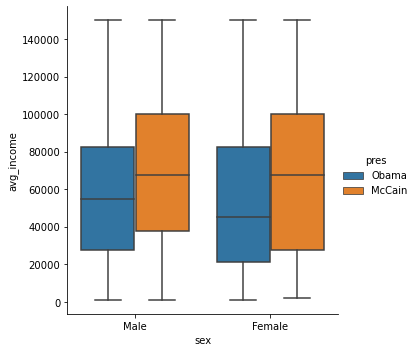

In [20]:
sns.catplot(x="sex",             # again, layout matters
            y="avg_income", 
            hue='pres',
            
            kind='box',                                         
            data=data)

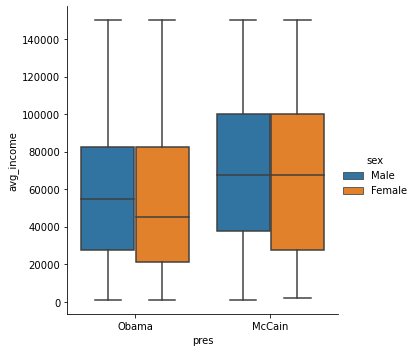

In [21]:
sns.catplot(x="pres",             # again, layout matters
            y="avg_income", 
            hue='sex',
            
            kind='box',                                         
            data=data)

### ▲ Again, different layouts tell different stories!

For a regular grouped box plots, **the Y axis should always be the numerical variable.**\
But which categorical variable should be **X**, and which categorical variable should be the **color hue**? 

Layout matters!

## 2. one numerical and three or more categorical variables <a id=2.2></a>
We can even expand the visualization to draw more comparisons between different groups. If necessary, we can visualize at least 4 variables at the same time with **faceting**. 

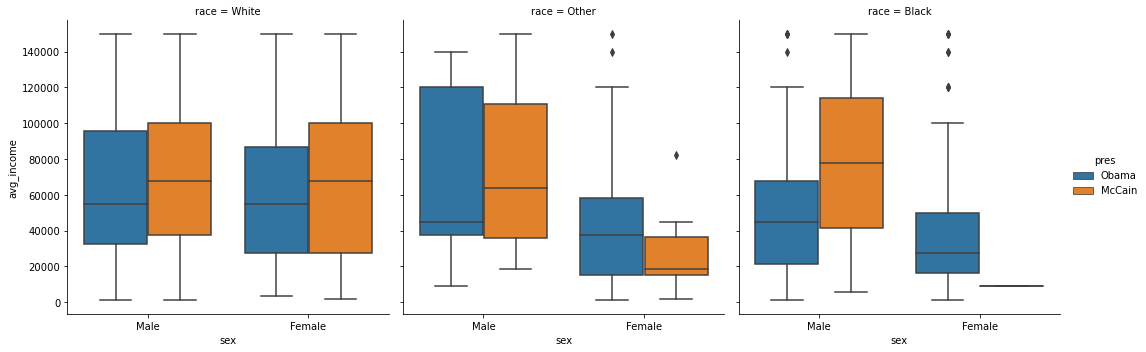

In [22]:
sns.catplot(x="sex", 
            y='avg_income', 
            hue='pres',
            
            col="race",                                # add faceting variable! 
            col_wrap=3,                                # i.e., wrap it to 3 columns
            
            kind='box',                                
            data=data)

### Faceting simple means adding more panels, so it is not limited to numerical v.s. categorical. 
### For instance, you can easily facet grouped/stacked bar plots to show the relationship between three categorical variables. 

However, the more variables you involve, the more difficult to interpret the findings/visualizations. I generally do not recommend you to go over 4 variables in one single analysis. 

### Again, layouts matter. 

While Y is always the numerical variable, which variable should be the X, which variable should be the faceting variable, and which should be the color hue? You may want to explore different layouts to determine which one serves your story best.

## 3. Two numerical variables and one categorical variable <a id=2.3></a>
The relationship between between two numerical variables, as we just reviewed, is called "correlation" and can be visualized as a scatterplot. **By adding a categorical variable, we are asking how this relationship may vary across different categories under that categorical variable.**

So, you may want to calculate the Pearson's r (correlation coefficients) for each categories first, and use a grouped scratter plot to visualize this multivariate relationship.

In [23]:
# correlation between income and tv hours for those whose education is high school and below 
data[data.educ_recoded=='high school and below'][['avg_income', 'tvhours']].corr()

,avg_income,tvhours
avg_income,1.00000,-0.21452
tvhours,-0.21452,1.00000


In [24]:
# correlation between income and tv hours for those whose education is some college
data[data.educ_recoded=='some college'][['avg_income', 'tvhours']].corr()

,avg_income,tvhours
avg_income,1.000000,-0.230041
tvhours,-0.230041,1.000000


In [25]:
# correlation between income and tv hours for those whose education is graduate level
data[data.educ_recoded=='graduate level'][['avg_income', 'tvhours']].corr()

,avg_income,tvhours
avg_income,1.000000,-0.277288
tvhours,-0.277288,1.000000


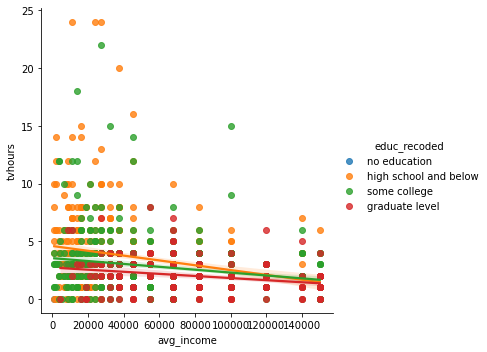

In [26]:
# visualize the correlation between income (numerical) and tvhours (numerical) by educational levels (categorical)

sns.lmplot(data = data,                 # dataframe where the variables come from 
           x = "avg_income",            # x axis, numerical
           y = "tvhours",               # y axis, numerical
           hue = "educ_recoded")        # color hue by education, categorical

### What if you want to visualize two numerical by two or more categorical variables? 
### Faceting! You can always add more panels to show the relationship across certain categories.  

## 4. Association between multiple numerical variables <a id=2.4></a>

We have talked about how to draw scatterplot and do correlation tests for two variables. One last thing is that, if you want to look at the paired correlation for multiple variables at the same time, we can make **a correlation matrix for all numerical variables** with the `df.corr()` command. Then visualizing it with `heatmaps`.

In [30]:
data.corr(numeric_only=True)                        # only numericals can have pearson's correlation coefficient/

TypeError: corr() got an unexpected keyword argument 'numeric_only'

In [28]:
data2 = df[['age', 'tvhours', 'sibs', 'childs']]
data2.corr()

,age,tvhours,sibs,childs
age,1.000000,0.157207,0.113670,0.375761
tvhours,0.157207,1.000000,0.066478,0.063900
sibs,0.113670,0.066478,1.000000,0.258432
childs,0.375761,0.063900,0.258432,1.000000


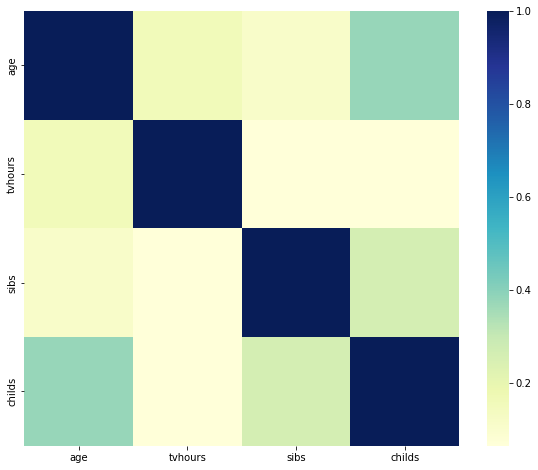

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))                    #  define fig size 

ax = sns.heatmap(data2.corr(),                             #   pass the matrix
                 cmap="YlGnBu",                            #   define colormap to use
                 square=True)  

Want to do correlations between ordinal variables (Spearman correlation)? Want to compute p values and/or significance levels for correlations? Not satisfied with correlations but hoping to do linear regression or logistic regression? Please check out the RealPython tutorials: ["Correlation with Python"](https://realpython.com/numpy-scipy-pandas-correlation-python/), [Linear Regression in Python](https://realpython.com/linear-regression-in-python/), and [Logistic Regression in Python](https://realpython.com/logistic-regression-python/).

Again, you need to grasp the data structures and the workflow of data analysis with Python. You also need to take good care of data pre-processing. Then for specific tasks and modelings, you can always ask Google or other online resources for help. 

# Saving Data <a id=4></a>

Finally, after we processed the data and/or obtained some outputs/visualizations, we may want to save them for future use. We've mentioned the commands before, but just to recap:

If you want to save any plots you made, then **after you make the plot(s), just use `plt.savefig('plot_name.jpg')`** to save the figure. You can also save the plots to other formats, change the `dpi` of the plots, or do other tweaks. Please refer to [the documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html) for more details. 

In [ ]:
sns.catplot(x="race", 
            y="avg_income", 
            hue='sex',
            
            kind='box',
            data=data)

plt.savefig('income_by_sex_and_race.jpg')                  # save the fig!

## check your working directory for the saved pic!

Except for plots, **you can also save the dataset or important statistics (in the format of Pd.Series or Pd.DataFrame) to a local document for future use**. Many formats are supported, including excel spreadsheet, CSV, stata, sql, .... Again, please refer to the [RealPython tutorial](https://realpython.com/pandas-read-write-files/) and/or the pandas [documentation](https://pandas.pydata.org/docs/reference/io.html) for more details. 

In [ ]:
data.info()

In [ ]:
data.head()

In [ ]:
data.to_csv('working_data.csv', index=False)

In [ ]:
pd.crosstab(index=data["pol"],
            columns=data["sex"],
            
            values=data["id"],
            aggfunc='count',
            margins=True)         

In [ ]:
stats = pd.crosstab(index=data["pol"],
            columns=data["sex"],
            
            values=data["id"],
            aggfunc='count',
            margins=True)                    

stats.to_excel('crosstab_by_sex_and_pol.xlsx', index=False)

### With this, we concluded our studying of data analysis with Python. There are too many to cover in just one semester. So this is more of a class that helps you open the door to the universe of Python.  

# There are still a lot to learn. Go figure!

---
Copyright &copy; 2024 Yinxian Zhang | Department of Sociology | City University of New York, Queens College